In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_PATH = '../data/'
file_name = 'df_ml.csv'

df = pd.read_csv(DATA_PATH+file_name, sep=',')
df_copy = df.copy()

df.shape

(17019, 34)

In [2]:
df.head(1)

,instant,season,year,month,hour,holiday,working_day,weather_sit,feeling_temp,hum,...,rolling_median_168,rolling_std_168,rolling_min_168,rolling_max_168,lag_1,lag_2,lag_8,lag_24,lag_72,lag_168
0,169,1,0,1,7,0,0,2,0.1818,0.74,...,49.0,51.220768,1.0,219.0,2.0,5.0,15.0,84.0,3.0,16.0


# Criação de novas features

### Variável para representar dia e noite

* 0: Dia
* 1: Noite

In [3]:
df['period'] = df['hour'].apply(lambda hour: 0 if 6 <= hour <= 18 else 1)

### Variável para representar horário de pico
* 0: Não
* 1: Sim

In [4]:
df['rush'] = df.apply(lambda row: 1 if (
    row['hour'] in [8, 17, 18]) and 
    row['working_day'] == 1
    else 0, axis=1)

In [5]:
TARGET_COLUMN = 'cnt'
NUMERIC_COLUMNS = ['feeling_temp']
CATEGORICAL_COLUMNS = ['weather_sit', 'month', 'season']

TO_NORMALIZE_BY_ROBUST = ['rolling_mean_6', 'rolling_median_6', 'rolling_std_6', 'rolling_min_6',
       'rolling_max_6', 'rolling_mean_24', 'rolling_median_24',
       'rolling_std_24', 'rolling_min_24', 'rolling_max_24',
       'rolling_mean_168', 'rolling_median_168', 'rolling_std_168',
       'rolling_min_168', 'rolling_max_168', 'lag_1', 'lag_2', 'lag_8',
       'lag_24', 'lag_72', 'lag_168']

TO_ENCODE_FEATURES_BY_DUMMY = ['working_day', 'period', 'rush']

# Separação do dataset para simular ambiente real

In [6]:
df_sim_real = df.iloc[-72:]
df = df.iloc[:-72]

# Dataset de treinamento

In [7]:
df_ml = df[
    NUMERIC_COLUMNS
    +CATEGORICAL_COLUMNS
    +TO_NORMALIZE_BY_ROBUST
    +TO_ENCODE_FEATURES_BY_DUMMY
    +[TARGET_COLUMN]
]

df_ml.head()

,feeling_temp,weather_sit,month,season,rolling_mean_6,rolling_median_6,rolling_std_6,rolling_min_6,rolling_max_6,rolling_mean_24,...,lag_1,lag_2,lag_8,lag_24,lag_72,lag_168,working_day,period,rush,cnt
0,0.1818,2,1,1,7.833333,6.0,6.675827,1.0,16.0,63.208333,...,2.0,5.0,15.0,84.0,3.0,16.0,0,0,0,9
1,0.1818,3,1,1,6.666667,6.0,5.465040,1.0,16.0,60.083333,...,9.0,2.0,25.0,210.0,33.0,40.0,0,0,0,15
2,0.1818,3,1,1,6.500000,6.0,5.128353,1.0,15.0,51.958333,...,15.0,9.0,16.0,134.0,88.0,32.0,0,0,0,20
3,0.1970,2,1,1,8.666667,7.0,7.554248,1.0,20.0,47.208333,...,20.0,15.0,16.0,63.0,195.0,13.0,0,0,0,61
4,0.1818,2,1,1,18.666667,12.0,21.750096,2.0,61.0,47.125000,...,61.0,20.0,7.0,67.0,115.0,1.0,0,0,0,62


In [8]:
df_ml.columns

Index(['feeling_temp', 'weather_sit', 'month', 'season', 'rolling_mean_6',
       'rolling_median_6', 'rolling_std_6', 'rolling_min_6', 'rolling_max_6',
       'rolling_mean_24', 'rolling_median_24', 'rolling_std_24',
       'rolling_min_24', 'rolling_max_24', 'rolling_mean_168',
       'rolling_median_168', 'rolling_std_168', 'rolling_min_168',
       'rolling_max_168', 'lag_1', 'lag_2', 'lag_8', 'lag_24', 'lag_72',
       'lag_168', 'working_day', 'period', 'rush', 'cnt'],
      dtype='object')

# Correlação das variáveis numericas

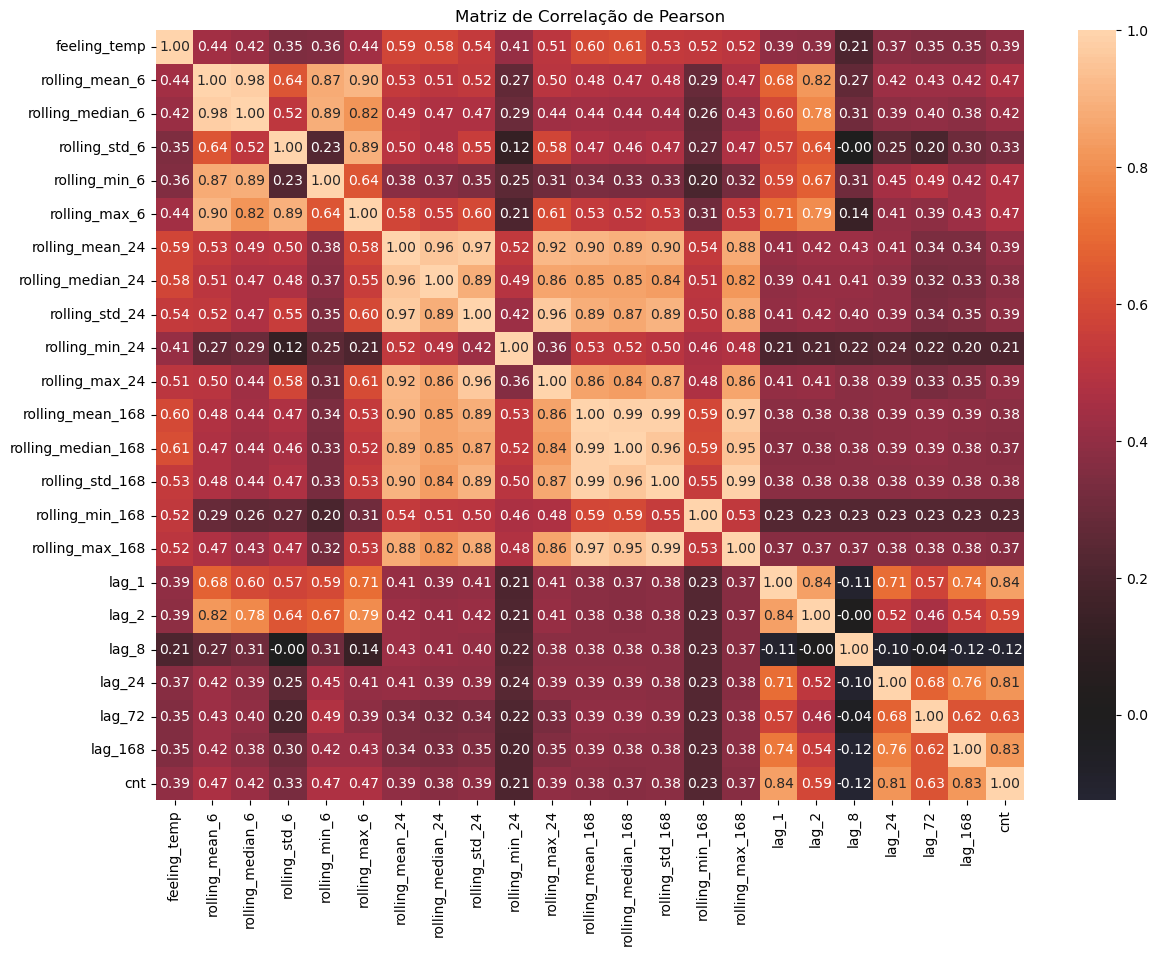

In [10]:
correlation_matrix = df[
    NUMERIC_COLUMNS
    +TO_NORMALIZE_BY_ROBUST
    +[TARGET_COLUMN]].corr(method='pearson')

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    center=0
)

plt.title('Matriz de Correlação de Pearson')
plt.show()

# Separação dos dados

In [11]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=24)

X = df_ml.drop(columns=[TARGET_COLUMN])
y = df_ml[TARGET_COLUMN]

splits = list(tscv.split(X))

# Seleção dos modelos
Na comparação entre os modelos avaliados, Linear Regression e XGBoost apresentaram maior estabilidade entre as métricas de treino e validação, com diferenças menores entre os resultados obtidos nos dois conjuntos.

Decision Tree, Random Forest e KNN apresentaram indícios mais evidentes de overfitting, caracterizados por um desempenho superior no conjunto de treino em relação à validação. Essa diferença sugere que esses modelos apresentaram maior dificuldade em generalizar para dados não utilizados durante o treinamento.

O Gradient Boosting não foi selecionado para as etapas seguintes devido ao maior custo computacional observado durante o treinamento e, principalmente, durante a busca por hiperparâmetros. Dessa forma, Linear Regression e KNN foram mantidos como alternativas para as etapas posteriores de avaliação e comparação.

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

def get_preprocessor():
    transformers = [
        ('robust', RobustScaler(), TO_NORMALIZE_BY_ROBUST),
        ('dummy', OneHotEncoder(drop='first', handle_unknown='ignore'), TO_ENCODE_FEATURES_BY_DUMMY),
    ]
    
    return ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'
    )


# TREINAMENTO DO MODELO
def fit_model(model, X_train, y_train, X_test, y_test):

    pipeline = Pipeline(
        steps=[
            ('preprocessor', get_preprocessor()),
            ('model', model)
        ]
    )
    
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    metrics = {
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Validation MAE': mean_absolute_error(y_test, y_test_pred),
        'Train RMSE': mean_squared_error(y_train, y_train_pred) ** 0.5,
        'Validation RMSE': mean_squared_error(y_test, y_test_pred) ** 0.5,
        'Train R2': r2_score(y_train, y_train_pred),
        'Validation R2': r2_score(y_test, y_test_pred)
    }

    return metrics

In [51]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

SEED = 42

# VALIDACÃO DO MODELO
def evaluate_train_validation(model, X):
    train_validation_metrics = []

    for fold, (train_index, test_index) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model_fold = clone(model)

        metrics = fit_model(model_fold, X_train, y_train, X_test, y_test)

        metrics['Fold'] = fold

        train_validation_metrics.append(metrics)

    train_validation_df = pd.DataFrame(train_validation_metrics)

    return train_validation_df

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


models = {
    'Linear Regression': LinearRegression(n_jobs=6),
    'Decision Tree': DecisionTreeRegressor(random_state=SEED),
    'Random Forest': RandomForestRegressor(random_state=SEED, n_jobs=6),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED),
    'XGBoost': XGBRegressor(random_state=SEED),
    'KNN': KNeighborsRegressor(weights='distance')
}

results = []

for model_name, model in models.items():
    fold_metrics = []

    for train_index, test_index in splits:
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        metrics = fit_model(model, X_train, y_train, X_test, y_test)
        fold_metrics.append(metrics)

    average_metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    average_metrics['Model'] = model_name

    results.append(average_metrics)

metrics_df = pd.DataFrame(results)

In [15]:
metrics_df

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,Model
0,40.399368,36.974850,58.752328,54.096366,0.896207,0.885450,Linear Regression
1,0.000000,35.183333,0.000000,53.085974,1.000000,0.861473,Decision Tree
2,8.298422,22.089250,13.654115,36.735654,0.994394,0.931804,Random Forest
3,28.072070,23.352907,41.616976,34.672476,0.947921,0.945165,Gradient Boosting
4,13.395866,22.352291,18.901888,33.290965,0.989255,0.948815,XGBoost
5,0.000003,27.346701,0.000011,39.826789,1.000000,0.913189,KNN


## Otimização dos hiperparâmetros

Foi realizada uma busca por melhores hiperparâmetros para o modelo, com o objetivo de encontrar uma configuração que apresentasse um equilíbrio adequado entre desempenho e capacidade de generalização.

In [20]:
from sklearn.model_selection import GridSearchCV

def do_grid_search(param_grid, model):

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=splits,
        scoring='neg_root_mean_squared_error',
        n_jobs=6
    )

    grid_search.fit(X, y)

    cv_results = pd.DataFrame(grid_search.cv_results_)

    return cv_results

In [21]:
xgb = XGBRegressor(random_state=SEED)

param_grid = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5],
    'model__min_child_weight': [1, 5, 10]
}
cv_results = do_grid_search(param_grid, xgb)

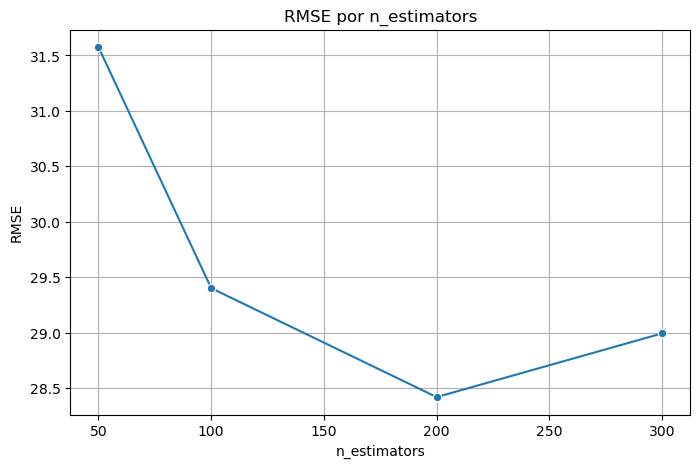

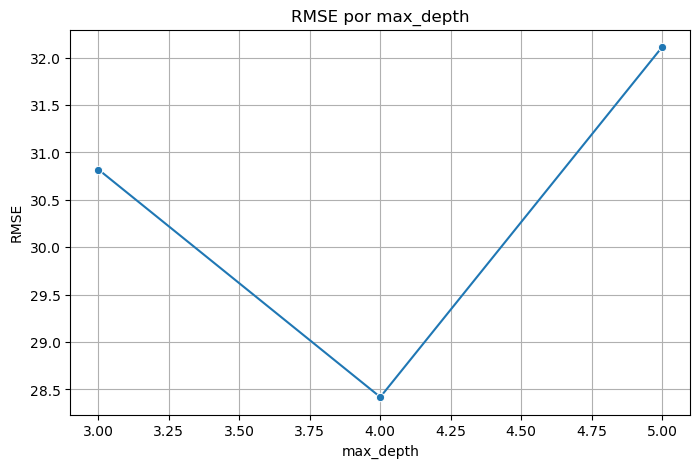

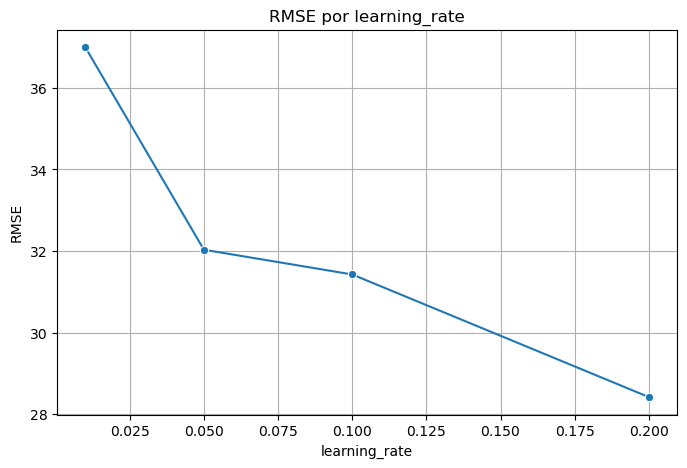

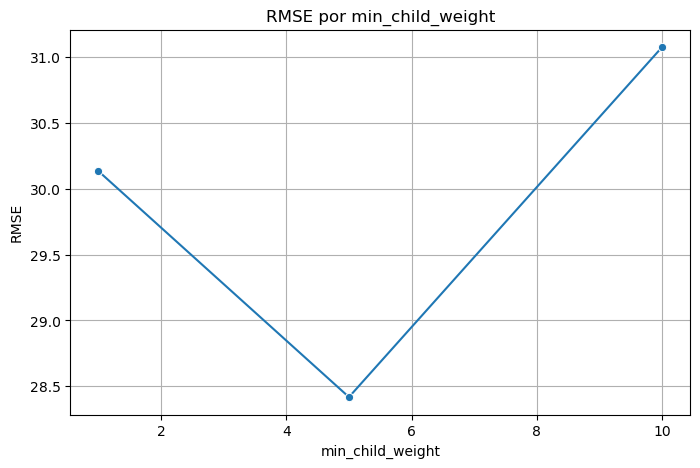

In [22]:
parameters = [
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__learning_rate',
    'param_model__min_child_weight',
]

for parameter in parameters:
    grouped_results = cv_results.groupby(parameter)['mean_test_score'].max().reset_index()
    grouped_results['RMSE'] = -grouped_results['mean_test_score']

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=grouped_results, x=parameter, y='RMSE', marker='o')
    plt.xlabel(parameter.replace('param_model__', ''))
    plt.ylabel('RMSE')
    plt.title(f'RMSE por {parameter.replace("param_model__", "")}')
    plt.grid(True)
    plt.show()

In [23]:
cv_results[cv_results['rank_test_score'] == 1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_weight,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
126,0.635309,0.006078,0.008276,0.000381,0.2,4,5,200,"{'model__learning_rate': 0.2, 'model__max_dept...",-42.920193,-21.788912,-25.90449,-16.282063,-35.192883,-28.417708,9.526344,1


# Selecionado XGBoost

O XGBoost foi selecionado por apresentar melhor desempenho nas métricas de validação quando comparado ao Linear Regression. O modelo apresentou RMSE médio na validação, menor que Linear Regression, indicando uma menor magnitude dos erros nas previsões realizadas sobre dados não utilizados no treinamento.

Apesar de apresentar maior variação entre os folds de validação, o XGBoost apresentou desempenho consistente na maior parte dos períodos avaliados. Nos folds 2, 3 e 4, foram observados valores de R² superiores a 0,97, enquanto os folds 1 e 5 apresentaram maior dificuldade de generalização. Esse comportamento indica que o desempenho do modelo pode variar de acordo com o período da série, mas o desempenho médio de validação permaneceu superior ao apresentado pelo Linear Regression.

Dessa forma, o XGBoost foi escolhido como modelo para as etapas seguintes, considerando seu menor erro de validação e sua maior capacidade de explicar a variabilidade da demanda em comparação ao Linear Regression.

## Métricas XGBoost

In [53]:
xgb = XGBRegressor(random_state=SEED, n_estimators=200, max_depth=4, learning_rate=0.2, min_child_weight=5)

df_result_grid = evaluate_train_validation(xgb, X)
df_result_grid

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,Fold
0,18.747047,30.314766,27.332339,42.920193,0.977552,0.883964,1
1,18.523653,16.943598,27.095871,21.788912,0.977923,0.982623,2
2,18.683420,17.702642,27.225084,25.904490,0.977706,0.980431,3
3,18.616764,11.563306,27.182484,16.282063,0.977778,0.992040,4
4,18.564432,17.571960,26.983014,35.192882,0.978104,0.949634,5


In [54]:
df_result_grid.mean()

Train MAE          18.627063
Validation MAE     18.819254
Train RMSE         27.163759
Validation RMSE    28.417708
Train R2            0.977813
Validation R2       0.957738
Fold                3.000000
dtype: float64

## Métricas LinearRegression

In [26]:
lr = LinearRegression(n_jobs=6)

df_result_grid = evaluate_train_validation(lr, X)
df_result_grid

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,Fold
0,40.411963,34.737026,58.765655,47.797338,0.896230,0.856095,1
1,40.401742,36.109482,58.751412,59.746637,0.896207,0.869344,2
2,40.393877,45.467302,58.752694,58.982974,0.896176,0.898545,3
3,40.399199,32.857956,58.752971,47.860848,0.896185,0.931220,4
4,40.390061,35.702482,58.738908,56.094034,0.896238,0.872045,5


In [27]:
df_result_grid.mean()

Train MAE          40.399368
Validation MAE     36.974850
Train RMSE         58.752328
Validation RMSE    54.096366
Train R2            0.896207
Validation R2       0.885450
Fold                3.000000
dtype: float64

In [28]:
best_model = xgb

# Análise dos erros do modelo ao longo do tempo

In [29]:
error_list = []

test_size = 24
initial_train_size = 24 * 30

for start in range(initial_train_size, len(X) - test_size + 1, test_size):
    train_end = start
    test_end = start + test_size

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_test = X.iloc[train_end:test_end]
    y_test = y.iloc[train_end:test_end]

    model = clone(best_model)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    fold_df = pd.DataFrame({
        'datetime': df.loc[X_test.index, 'datetime'],
        'y_true': y_test,
        'y_pred': y_pred
    })

    error_list.append(fold_df)

df_error = pd.concat(error_list, ignore_index=True)
df_error.shape

(16224, 3)

In [30]:
df_error['error'] = df_error['y_true'] - df_error['y_pred']
df_error['absolute_error'] = df_error['error'].abs()

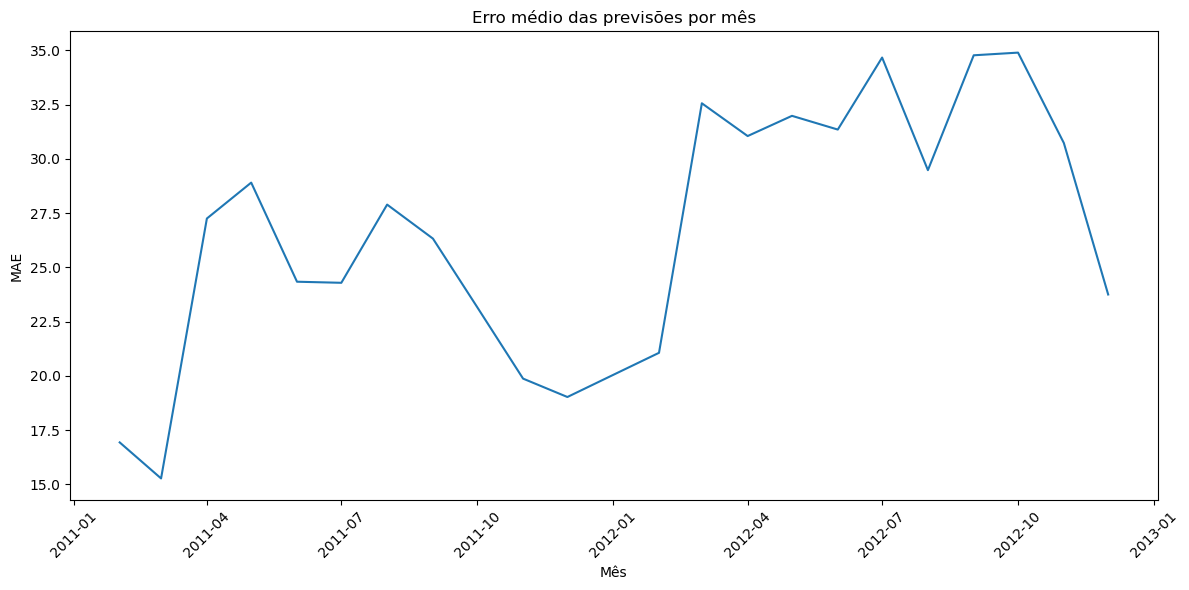

In [31]:
df_error['datetime'] = pd.to_datetime(df_error['datetime'])

monthly_error = (
    df_error
    .assign(month=df_error['datetime'].dt.to_period('M'))
    .groupby('month')[['absolute_error', 'y_true', 'y_pred']]
    .mean()
    .reset_index()
)

monthly_error['month'] = monthly_error['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly_error, x='month', y='absolute_error')

plt.xlabel('Mês')
plt.ylabel('MAE')
plt.title('Erro médio das previsões por mês')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparação da demanda real x predita pelo modelo

Nesta etapa, comparamos os valores reais de demanda com os valores preditos pelo modelo ao longo do tempo, buscando identificar como as previsões se comportam em relação aos dados observados.

In [32]:
def plot_demand(df, x):
    plt.figure(figsize=(14, 6))

    sns.lineplot(
        data=df,
        x=x,
        y='y_true',
        label='Demanda real'
    )
    
    sns.lineplot(
        data=df,
        x=x,
        y='y_pred',
        label='Demanda prevista'
    )
    
    plt.xlabel('Data')
    plt.ylabel('Demanda')
    plt.title('Demanda real × demanda prevista no período de teste')
    plt.legend()
    plt.tight_layout()
    plt.show()

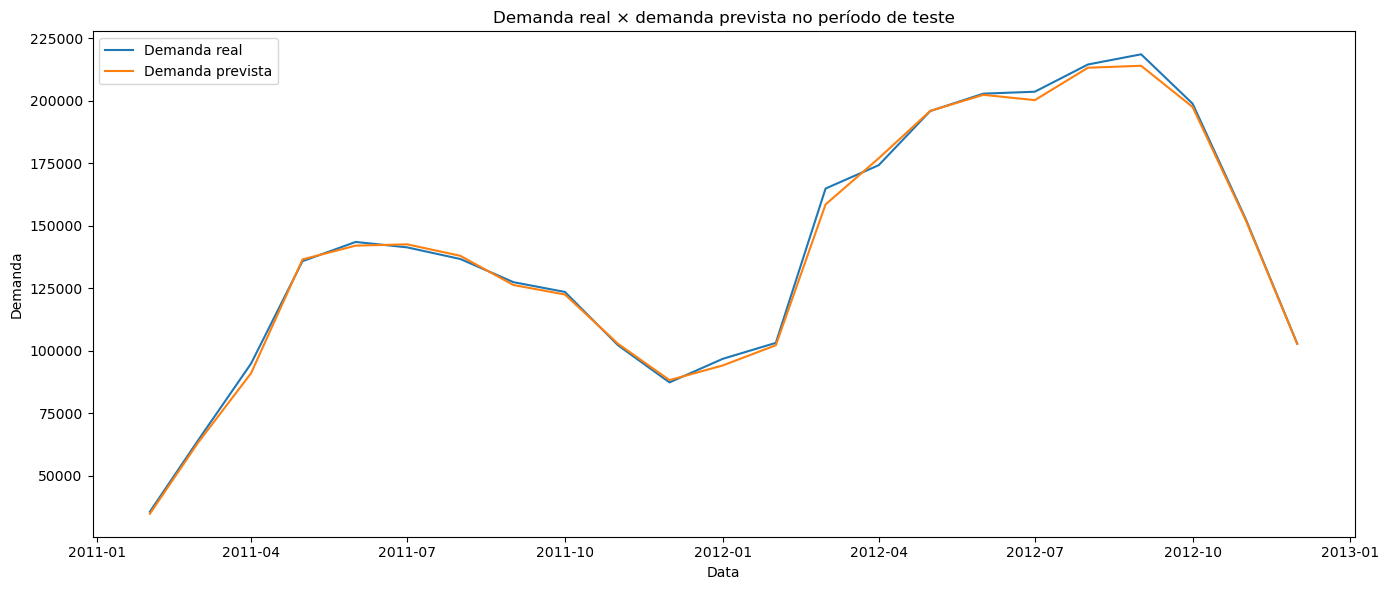

In [33]:
monthly_error = (
    df_error
    .assign(month=df_error['datetime'].dt.to_period('M'))
    .groupby('month')[['absolute_error', 'y_true', 'y_pred']]
    .sum()
    .reset_index()
)

monthly_error['month'] = monthly_error['month'].dt.to_timestamp()

plot_demand(monthly_error, 'month')


## Baixa demanda

Foi realizada uma análise da demanda real em comparação com a demanda predita durante um período de baixa demanda. Nesse recorte, as previsões acompanham as variações observadas na demanda real.

### Demanda em dezembro de 2011

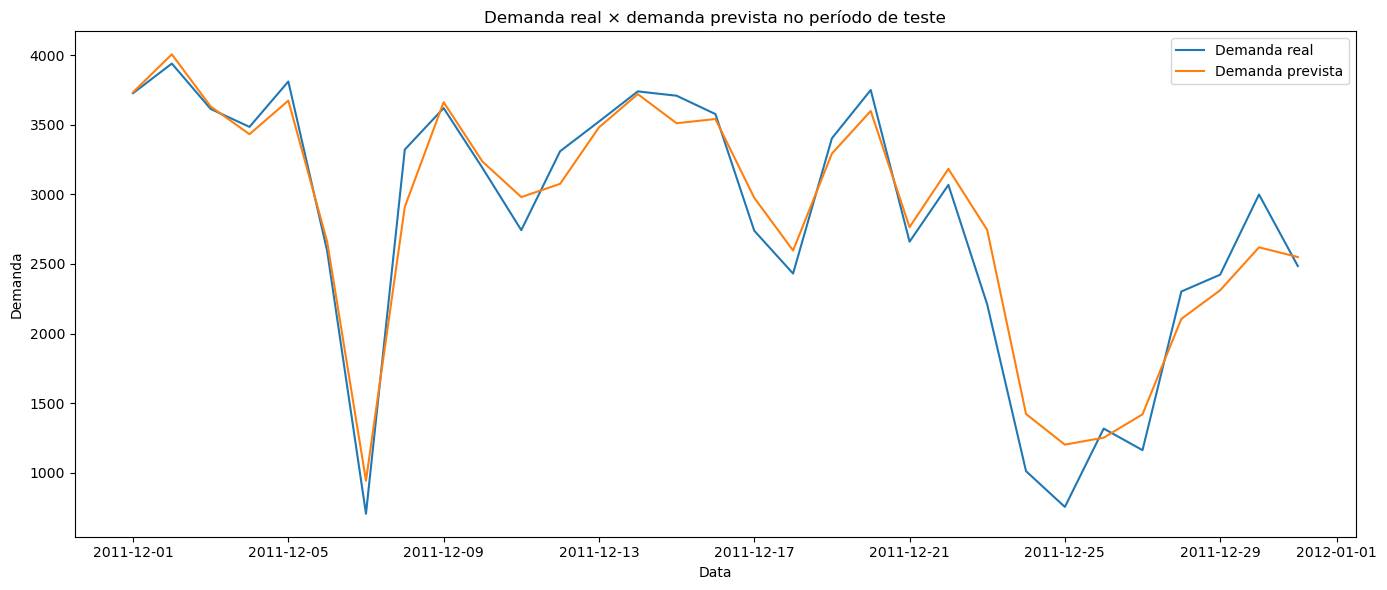

In [34]:
def demand_by_month(month, year):
    
    df_demand = df_error[(df_error['datetime'].dt.month == month) & (df_error['datetime'].dt.year == year)]
    
    df_demand = (
        df_demand
        .assign(day=df_demand['datetime'].dt.to_period('d'))
        .groupby('day')[['absolute_error', 'y_true', 'y_pred']]
        .sum()
        .reset_index()
    )
    
    df_demand['day'] = df_demand['day'].dt.to_timestamp()
    
    return df_demand

df_low_demand_by_day = demand_by_month(12, 2011)
plot_demand(df_low_demand_by_day, 'day')

### Demanda em dezembro de 2011 entre os dias 6 e 8

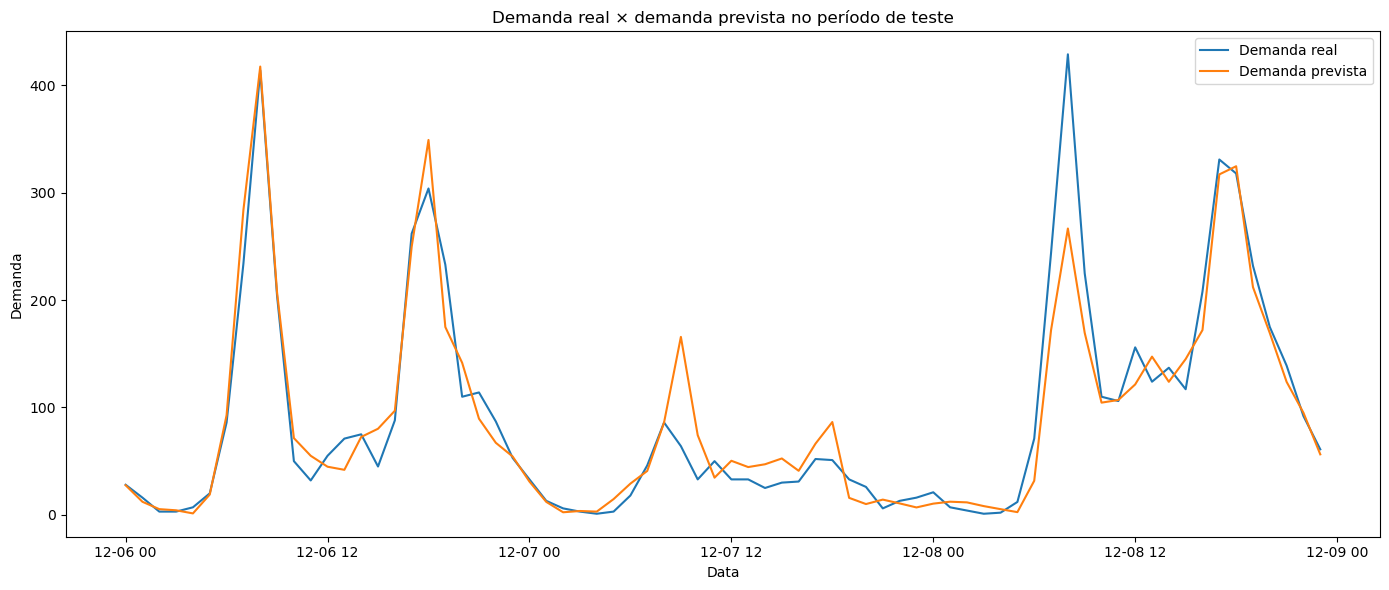

In [35]:
def demand_by_hour(year, month, start_day, end_day):
    
    df_demand = df_error[
    (df_error['datetime'].dt.year == year) &
    (df_error['datetime'].dt.month == month) &
    (df_error['datetime'].dt.day.between(start_day, end_day))
    ]
    
    df_demand = (
        df_demand
        .assign(hour=df_demand['datetime'].dt.to_period('h'))
        .groupby('hour')[['absolute_error', 'y_true', 'y_pred']]
        .sum()
        .reset_index()
    )
    
    df_demand['hour'] = df_demand['hour'].dt.to_timestamp()
    
    return df_demand

df_low_demand_by_hour = demand_by_hour(2011, 12, 6, 8)
plot_demand(df_low_demand_by_hour, 'hour')

## Alta demanda
Foi realizada uma análise da demanda real em comparação com a demanda predita durante um período de alta demanda. Nesse recorte, as previsões acompanham as variações observadas na demanda real.

### Demanda em setembro de 2012

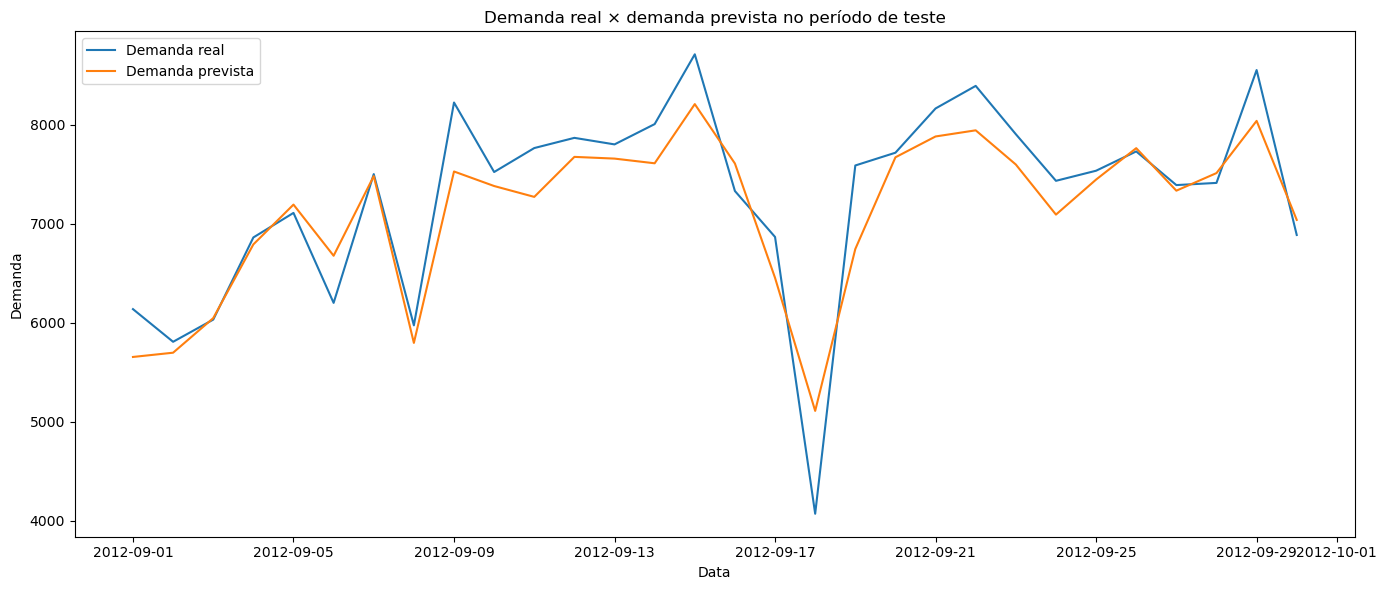

In [36]:
df_high_demand_by_day = demand_by_month(9, 2012)
plot_demand(df_high_demand_by_day, 'day')

### Demanda em setembro de 2012 entre os dias 14 e 16

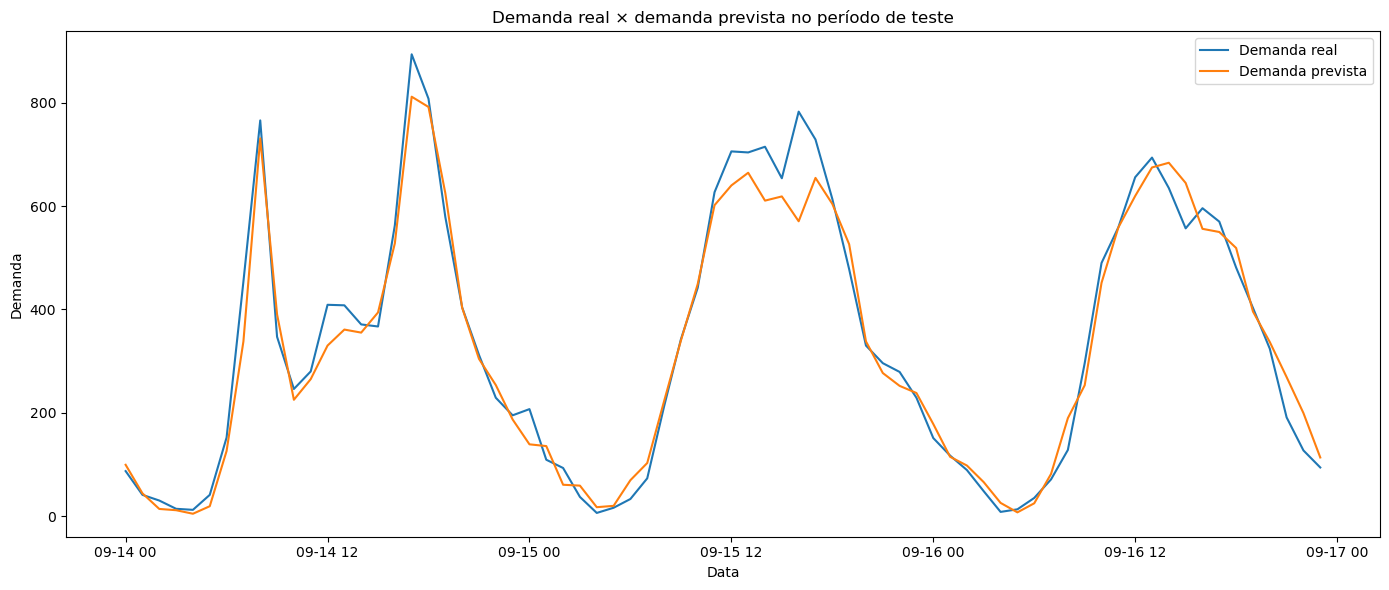

In [37]:
df_low_demand_by_hour = demand_by_hour(2012, 9, 14, 16)
plot_demand(df_low_demand_by_hour, 'hour')

# Feature Importance

A Permutation Importance foi utilizada para avaliar a contribuição de cada variável para o desempenho do modelo. O método consiste em embaralhar os valores de uma variável no conjunto de validação e observar quanto o desempenho do modelo é afetado. Quanto maior a redução no desempenho após o embaralhamento, maior a importância da variável para as previsões. O procedimento foi repetido em diferentes folds e com múltiplas repetições, permitindo avaliar tanto a importância média quanto sua variabilidade. Essa técnica mede a contribuição da variável para o desempenho do modelo, mas não representa causalidade.

In [38]:
from sklearn.inspection import permutation_importance

def permutation(model, splits_param, X_param, y_param):
    permutation_results = []

    for fold, (train_index, test_index) in enumerate(splits_param, start=1):
        X_train, X_test = X_param.iloc[train_index], X_param.iloc[test_index]
        y_train, y_test = y_param.iloc[train_index], y_param.iloc[test_index]
    
        model_fold = clone(model)
        model_fold.fit(X_train, y_train)
    
        result = permutation_importance(
            model_fold,
            X_test,
            y_test,
            scoring='neg_root_mean_squared_error',
            n_repeats=10,
            random_state=SEED
        )
    
        for feature, importance in zip(X_param.columns, result.importances_mean):
            permutation_results.append({
                'Fold': fold,
                'Feature': feature,
                'Importance': importance
            })
    
    permutation_df = pd.DataFrame(permutation_results)
    
    permutation_df.sort_values(['Fold', 'Importance'], ascending=[True, False])
    
    permutation_mean = (
        permutation_df.groupby('Feature')['Importance']
        .agg(['mean', 'std'])
        .sort_values('mean', ascending=False)
        .reset_index()
    )
    
    return permutation_mean

In [39]:
permutation(best_model, splits, X, y)

,Feature,mean,std
0,lag_1,154.347378,24.922980
1,rush,36.550526,22.348507
2,rolling_median_6,17.917736,10.955390
3,period,16.835048,6.620560
4,lag_2,16.137784,7.971836
5,lag_8,10.561567,6.015126
6,rolling_min_6,7.449560,4.889076
7,lag_168,6.879035,3.077157
8,rolling_max_6,5.240760,2.811199
9,lag_24,4.770929,3.025499


# Simulação de previsão

Foi realizada uma simulação de previsão utilizando 72 registros que não foram apresentados ao modelo durante o treinamento. O objetivo foi avaliar o comportamento do modelo em dados não utilizados no processo de ajuste, permitindo verificar sua capacidade de generalização em um cenário mais próximo da aplicação prática.

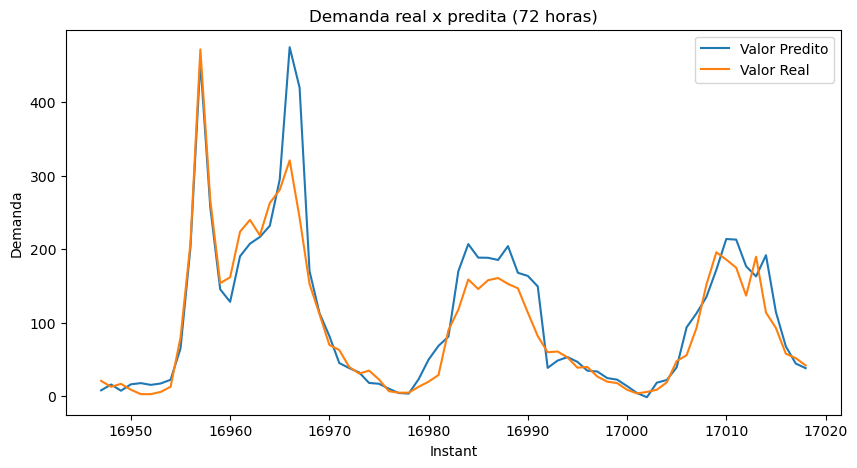

In [40]:
best_model.fit(X, y)

y_pred = best_model.predict(df_sim_real[
    NUMERIC_COLUMNS
    +CATEGORICAL_COLUMNS
    +TO_NORMALIZE_BY_ROBUST
    +TO_ENCODE_FEATURES_BY_DUMMY
    ])
y_true = df_sim_real[TARGET_COLUMN]

df_result_sim = pd.DataFrame({'Valor Predito': y_pred, 'Valor Real': y_true})


plt.figure(figsize=(10, 5))

sns.lineplot(data=df_result_sim, x=df_result_sim.index, y='Valor Predito', label='Valor Predito')
sns.lineplot(data=df_result_sim, x=df_result_sim.index, y='Valor Real', label='Valor Real')

plt.xlabel('Instant')
plt.ylabel('Demanda')
plt.title('Demanda real x predita (72 horas)')
plt.legend()
plt.show()

# Redução das features

Após a análise das variáveis mais importantes para o modelo, foi realizada uma nova etapa de treinamento utilizando apenas as features consideradas mais relevantes. O objetivo foi verificar se a remoção das variáveis com menor contribuição resultaria em uma perda significativa de desempenho.

No modelo original, o MAE de treino foi de 18,59 e o de validação de 20,72. Após a redução das features, esses valores passaram para 19,82 e 21,22, respectivamente. Portanto, houve um aumento de aproximadamente 1,23 no MAE de treino e 0,50 no MAE de validação, indicando uma pequena elevação no erro absoluto das previsões.

O RMSE apresentou comportamento semelhante. O valor de validação passou de 30,54 para 30,97, uma diferença de aproximadamente 0,44. Como o RMSE atribui maior peso aos erros mais elevados, essa pequena variação indica que a remoção das features não provocou um aumento relevante nos erros maiores.

Em relação ao R², o modelo original apresentou 0,9512 na validação, enquanto o modelo reduzido apresentou 0,9527. Apesar da pequena diferença, o resultado indica que o modelo reduzido manteve praticamente a mesma capacidade de explicar a variabilidade da demanda, apresentando inclusive uma variação positiva de aproximadamente 0,0015.

Além do desempenho de validação, também é importante observar a diferença entre as métricas de treino e validação. No modelo original, a diferença de MAE foi de aproximadamente 2,13, enquanto no modelo reduzido foi de aproximadamente 1,40. Para o RMSE, essa diferença passou de aproximadamente 3,57 para 1,78. Essa redução na distância entre treino e validação indica um comportamento mais próximo entre os dois conjuntos, reduzindo os indícios de overfitting observados no modelo original.

Dessa forma, a redução das features manteve o desempenho de validação praticamente inalterado, enquanto reduziu a complexidade do modelo. Esse resultado indica que parte das variáveis removidas apresentava contribuição limitada para o desempenho preditivo, permitindo obter um modelo mais simples sem uma perda relevante de capacidade de generalização.

In [41]:
CATEGORICAL_COLUMNS = ['weather_sit']

TO_NORMALIZE_BY_ROBUST = ['rolling_median_6', 'rolling_min_6',
       'rolling_max_6', 'lag_1', 'lag_2', 'lag_8',
       'lag_24', 'lag_168']

TO_ENCODE_FEATURES_BY_DUMMY = ['working_day', 'period', 'rush']

df_ml_2 = df[
    NUMERIC_COLUMNS
    +CATEGORICAL_COLUMNS
    +TO_NORMALIZE_BY_ROBUST
    +TO_ENCODE_FEATURES_BY_DUMMY
    +[TARGET_COLUMN]
]
    

df_ml_2.head()


,feeling_temp,weather_sit,rolling_median_6,rolling_min_6,rolling_max_6,lag_1,lag_2,lag_8,lag_24,lag_168,working_day,period,rush,cnt
0,0.1818,2,6.0,1.0,16.0,2.0,5.0,15.0,84.0,16.0,0,0,0,9
1,0.1818,3,6.0,1.0,16.0,9.0,2.0,25.0,210.0,40.0,0,0,0,15
2,0.1818,3,6.0,1.0,15.0,15.0,9.0,16.0,134.0,32.0,0,0,0,20
3,0.1970,2,7.0,1.0,20.0,20.0,15.0,16.0,63.0,13.0,0,0,0,61
4,0.1818,2,12.0,2.0,61.0,61.0,20.0,7.0,67.0,1.0,0,0,0,62


In [42]:
tscv2 = TimeSeriesSplit(n_splits=5, test_size=24)

X2 = df_ml_2.drop(columns=[TARGET_COLUMN])
y2 = df_ml_2[TARGET_COLUMN]

splits2 = list(tscv.split(X2))

In [43]:
# VALIDACÃO DO MODELO
def evaluate_train_validation2(model, X_param, y_param, splits_param):
    train_validation_metrics = []

    for fold, (train_index, test_index) in enumerate(splits_param, start=1):
        X_train, X_test = X_param.iloc[train_index], X_param.iloc[test_index]
        y_train, y_test = y_param.iloc[train_index], y_param.iloc[test_index]

        model_fold = clone(model)

        metrics = fit_model(model_fold, X_train, y_train, X_test, y_test)

        metrics['Fold'] = fold

        train_validation_metrics.append(metrics)

    train_validation_df = pd.DataFrame(train_validation_metrics)

    return train_validation_df

In [55]:
xgb2 = XGBRegressor(random_state=SEED, n_estimators=200, max_depth=4, learning_rate=0.2, min_child_weight=1)

df_result_grid2 = evaluate_train_validation2(xgb2, X2, y2, splits2)
df_result_grid2

,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2,Fold
0,19.910788,31.994730,29.329605,45.901620,0.974151,0.867283,1
1,19.655991,19.005760,28.918913,25.467862,0.974852,0.976260,2
2,19.736300,21.218594,29.085235,29.260982,0.974556,0.975031,3
3,19.863535,16.397879,29.317114,23.257711,0.974151,0.983758,4
4,19.920740,17.479450,29.336152,30.976286,0.974118,0.960980,5


In [56]:
df_result_grid2.mean()

Train MAE          19.817471
Validation MAE     21.219283
Train RMSE         29.197404
Validation RMSE    30.972892
Train R2            0.974366
Validation R2       0.952663
Fold                3.000000
dtype: float64

### Feature importance xgb2

In [57]:
permutation(xgb2, splits2, X2, y2)

,Feature,mean,std
0,lag_1,167.873027,27.502728
1,rush,27.181906,16.639793
2,lag_2,24.857866,12.877258
3,rolling_median_6,17.816717,9.443377
4,period,17.018978,4.966547
5,lag_8,15.013054,8.027871
6,lag_168,11.760010,6.340514
7,rolling_min_6,9.618430,4.877502
8,lag_24,4.644585,2.771126
9,weather_sit,3.390115,3.551346
